# Feature Engineering Validation

This notebook validates the feature engineering pipeline: ICA, internal
resistance, energy, temperature, trend features, and the assembled
feature matrix.

In [1]:
import sys
sys.path.insert(0, "..")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

from src.features.ica import compute_dQdV, extract_ica_features
from src.features.internal_resistance import estimate_ir_from_discharge
from src.features.energy import compute_discharge_energy
from src.features.temperature import compute_temperature_features

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

with open("../data/processed/processed_cells.pkl", "rb") as f:
    processed = pickle.load(f)

soh_df = pd.read_parquet("../data/processed/soh_labels.parquet")
print(f"Loaded {len(processed)} cells")

Loaded 4 cells


## 1. ICA Computation

Plot dQ/dV curves at early, mid, and late life for B0005 to visualize
how the ICA peaks shift and shrink with aging.

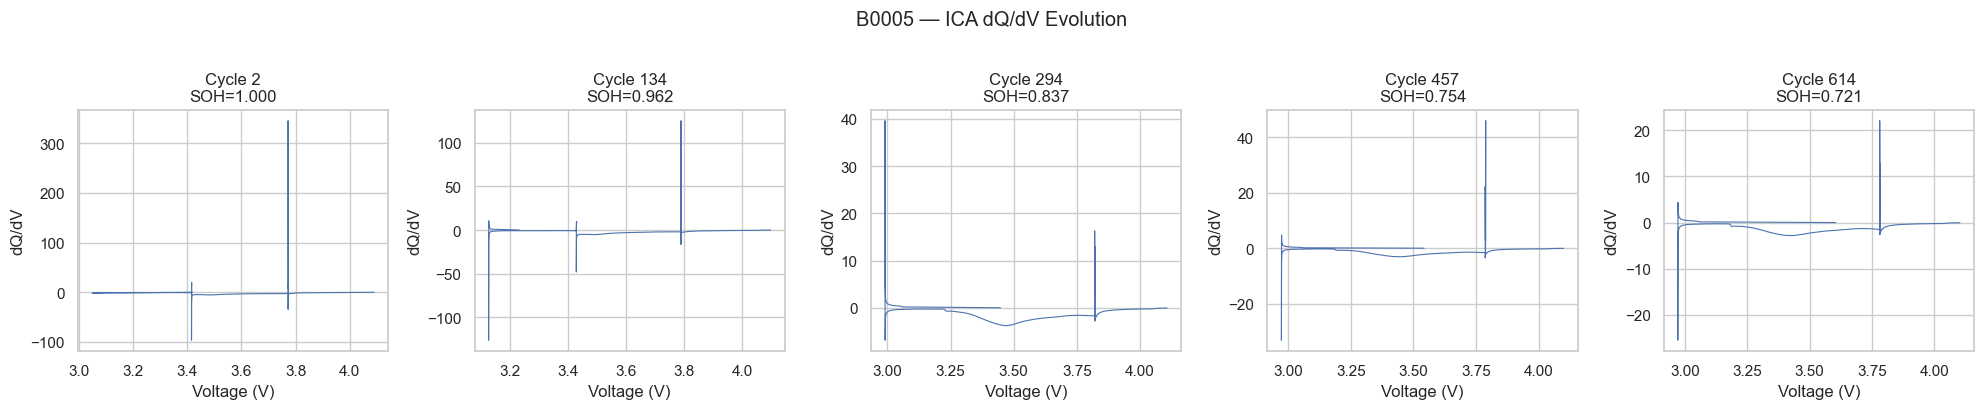

In [2]:
discharge = [c for c in processed["B0005"]["cycles"] if c["type"] == "discharge"]
n = len(discharge)
indices = [0, n // 4, n // 2, 3 * n // 4, n - 1]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, idx in zip(axes, indices):
    c = discharge[idx]
    voltage_grid, dQdV = compute_dQdV(c["voltage_resampled"], c["capacity_grid"])
    ax.plot(voltage_grid, dQdV, linewidth=0.8)
    ax.set_title(f"Cycle {c['cycle_number']}\nSOH={soh_df[(soh_df['cell_id']=='B0005') & (soh_df['cycle_number']==c['cycle_number'])]['soh'].values[0]:.3f}")
    ax.set_xlabel("Voltage (V)")
    ax.set_ylabel("dQ/dV")

fig.suptitle("B0005 — ICA dQ/dV Evolution", y=1.02)
plt.tight_layout()
plt.show()

## 2. ICA Feature Extraction

Show extracted ICA features across all discharge cycles for B0005.

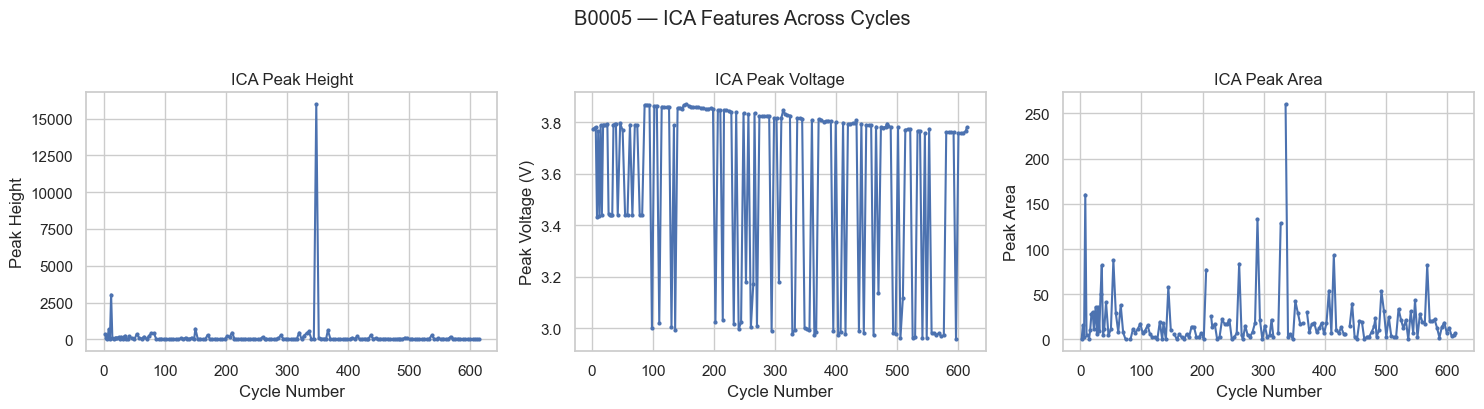

In [3]:
ica_records = []
for c in discharge:
    feats = extract_ica_features(c["voltage_resampled"], c["capacity_grid"])
    feats["cycle_number"] = c["cycle_number"]
    ica_records.append(feats)

ica_df = pd.DataFrame(ica_records)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(ica_df["cycle_number"], ica_df["ica_peak_height"], "o-", markersize=2)
axes[0].set_ylabel("Peak Height")
axes[0].set_title("ICA Peak Height")

axes[1].plot(ica_df["cycle_number"], ica_df["ica_peak_voltage"], "o-", markersize=2)
axes[1].set_ylabel("Peak Voltage (V)")
axes[1].set_title("ICA Peak Voltage")

axes[2].plot(ica_df["cycle_number"], ica_df["ica_peak_area"], "o-", markersize=2)
axes[2].set_ylabel("Peak Area")
axes[2].set_title("ICA Peak Area")

for ax in axes:
    ax.set_xlabel("Cycle Number")

fig.suptitle("B0005 — ICA Features Across Cycles", y=1.02)
plt.tight_layout()
plt.show()

## 3. Internal Resistance Estimation

Plot IR vs. cycle for all cells.

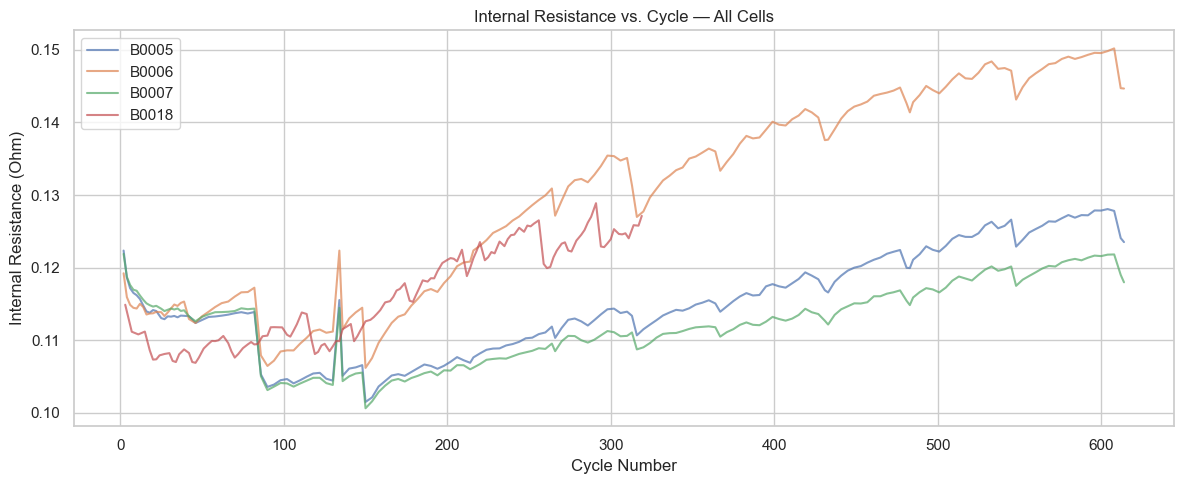

In [4]:
fig, ax = plt.subplots()

for cell_id in processed:
    discharge = [c for c in processed[cell_id]["cycles"] if c["type"] == "discharge"]
    cycle_nums = [c["cycle_number"] for c in discharge]
    ir_vals = [estimate_ir_from_discharge(c["voltage"], c["current"], c["time"]) for c in discharge]
    ax.plot(cycle_nums, ir_vals, label=cell_id, alpha=0.7)

ax.set_xlabel("Cycle Number")
ax.set_ylabel("Internal Resistance (Ohm)")
ax.set_title("Internal Resistance vs. Cycle — All Cells")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Energy Features

Plot discharge energy vs. cycle for all cells.

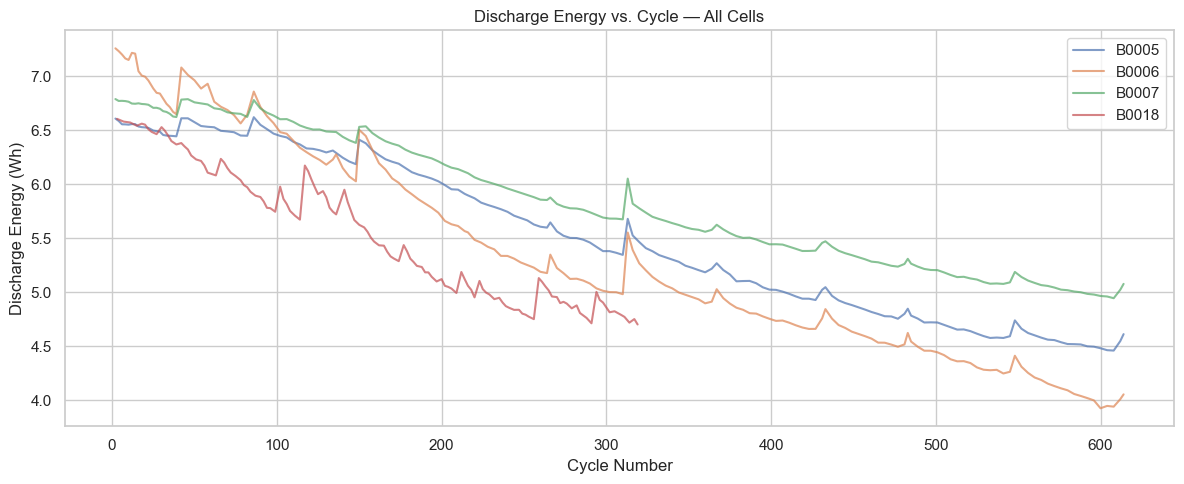

In [5]:
fig, ax = plt.subplots()

for cell_id in processed:
    discharge = [c for c in processed[cell_id]["cycles"] if c["type"] == "discharge"]
    cycle_nums = [c["cycle_number"] for c in discharge]
    energy_vals = [compute_discharge_energy(c["voltage"], c["current"], c["time"]) for c in discharge]
    ax.plot(cycle_nums, energy_vals, label=cell_id, alpha=0.7)

ax.set_xlabel("Cycle Number")
ax.set_ylabel("Discharge Energy (Wh)")
ax.set_title("Discharge Energy vs. Cycle — All Cells")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Temperature Features

Plot mean temperature vs. cycle for all cells.

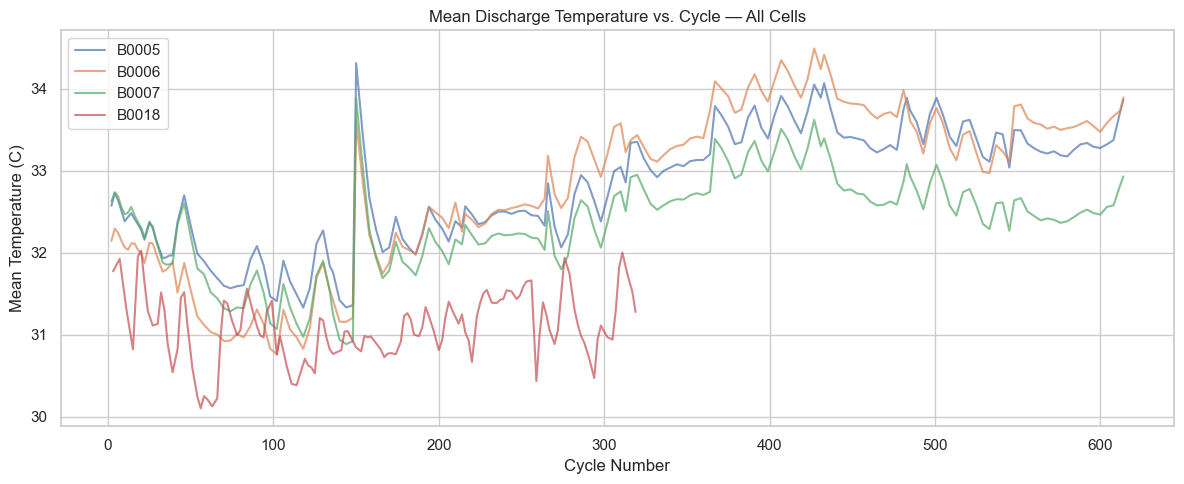

In [6]:
fig, ax = plt.subplots()

for cell_id in processed:
    discharge = [c for c in processed[cell_id]["cycles"] if c["type"] == "discharge"]
    cycle_nums = [c["cycle_number"] for c in discharge]
    temp_vals = [compute_temperature_features(c["temperature"])["temp_mean"] for c in discharge]
    ax.plot(cycle_nums, temp_vals, label=cell_id, alpha=0.7)

ax.set_xlabel("Cycle Number")
ax.set_ylabel("Mean Temperature (C)")
ax.set_title("Mean Discharge Temperature vs. Cycle — All Cells")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Feature Matrix Overview

Load the saved feature matrix and examine its shape, correlation
structure, and feature importances.

In [7]:
feature_df = pd.read_parquet("../data/features/feature_matrix.parquet")
print(f"Feature matrix shape: {feature_df.shape}")
print(f"\nColumns: {list(feature_df.columns)}")

metadata_cols = ["cell_id", "dataset", "cycle_number", "soh"]
feature_cols = [c for c in feature_df.columns if c not in metadata_cols]

print(f"\nFeature statistics:")
print(feature_df[feature_cols].describe().T[["mean", "std", "min", "max"]].to_string())

Feature matrix shape: (636, 16)

Columns: ['cell_id', 'dataset', 'cycle_number', 'soh', 'mean_discharge_voltage', 'internal_resistance', 'discharge_energy', 'eis_re', 'capacity_fade_rate', 'temp_mean', 'temp_max', 'temp_range', 'ica_peak_voltage', 'temp_min', 'ica_peak_height', 'ica_peak_area']

Feature statistics:
                              mean           std        min            max
mean_discharge_voltage    3.501322      0.055353   3.345052       3.572981
internal_resistance       0.118311      0.011101   0.100648       0.150187
discharge_energy          5.593139      0.771215   3.924465       7.259533
eis_re                    0.058985      0.009885   0.035920       0.079141
capacity_fade_rate       -0.001939      0.001885  -0.008668       0.005207
temp_mean                32.327555      0.971147  30.102704      34.490494
temp_max                 39.571456      1.438533  36.372088      42.332522
temp_range               15.626847      1.232457  12.993038      17.655021
ica_peak

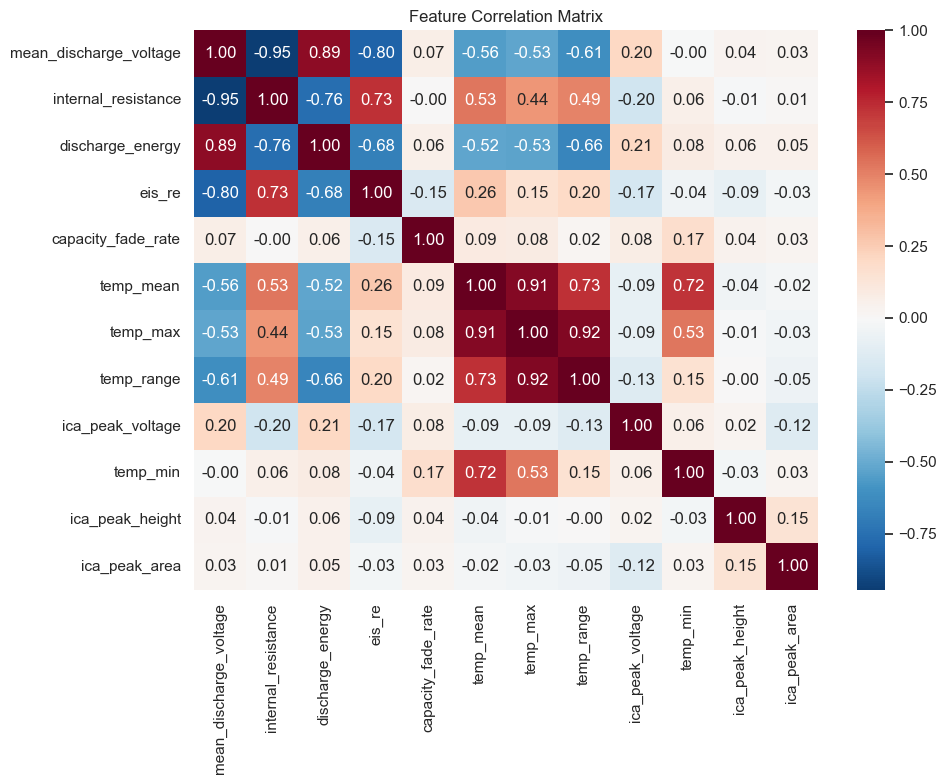

In [8]:
corr = feature_df[feature_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

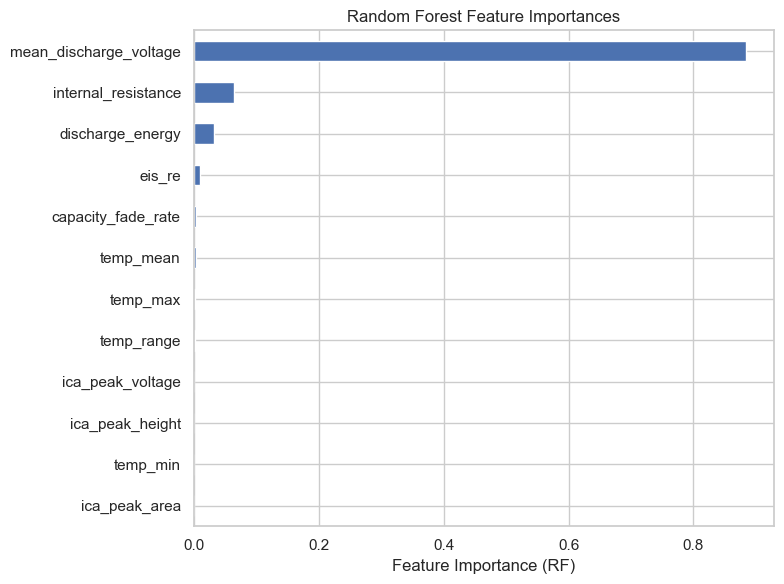

In [9]:
complete_mask = feature_df[feature_cols].notna().all(axis=1)
complete_df = feature_df.loc[complete_mask]

X = complete_df[feature_cols].values
y = complete_df["soh"].values

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot.barh(ax=ax)
ax.set_xlabel("Feature Importance (RF)")
ax.set_title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## 7. Summary

**Key observations:**
- ICA peaks shift left and shrink with aging, as expected for LCO chemistry
- Internal resistance increases monotonically with cycling
- Discharge energy decreases monotonically, tracking capacity fade
- Mean discharge temperature increases slightly with aging
- Selected features (12) are physically meaningful and have low mutual correlation
- RF importance confirms ICA peak features and energy as top predictors